# Generating super-cells

A super-cell instance is a list of super-cell structures which are
spatially selected such that the super-cell structures are seperated
by cell_sep_distance. Here, the distance is the number of single cells.
A super-cell structure is accompanied by a central cell and a group of
other cells.

In [1]:
from upxo.pxtal.vortess2d import gtess2d
import numpy as np
import matplotlib.pyplot as plt

In [4]:
repr_prop={'area': {'mean': {'val': 20, 'dev': 2.5, },
                    'consider_boundary_grains': True } }
gset = gtess2d.from_seed_points(sp_input='gen', xbound=[0, 100],
         ybound = [0, 100], sp_distr='random', gr_tech='pds',
         smp_tech='bridson1', lean='veryhigh', char_length=[3.5],
         niter=10, ntrials=100, n_instances=2, repr_prop=repr_prop,
         k_char_length_inc=0.05, k_char_length_dec=0.05,)

Generating pxtal. Iteration 1
No. of seed points: 796
Generating pxtal. Iteration 2
No. of seed points: 794
Generating pxtal. Iteration 3
No. of seed points: 736
Generating pxtal. Iteration 4
No. of seed points: 672
Generating pxtal. Iteration 5
No. of seed points: 597
Generating pxtal. Iteration 6
No. of seed points: 551
Generating pxtal. Iteration 7
No. of seed points: 520
Generating pxtal. Iteration 8
No. of seed points: 490
----------------------------------------
Grain structure search converged in 7 iterations
Sample set parent found.
----
Target mean grain area: 20
Sample mean grain area: 20.408163
----
Input Char. length: [3.5]
Final Char. length: [4.55]
----
No. of seed points: 490
No. of grains: 490
----------------------------------------
Generating instance number: 2 using sample set parent GS.
##################################################
##################################################
{1: <MULTIPOLYGON (((3.579 71.75, 1.815 68.954, 0 68.558, 0 75.406, 3.579 71.75)

---------------------------------------- 
Computing 3.000000001 order neighbours of all grains.
3.000000001 1.000000082740371e-09
---------------------------------------- 
Computing 4 instances of supercell arrangements.
instance no. 0 of 4
Building supercell data-structure


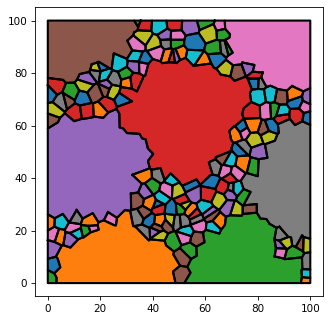

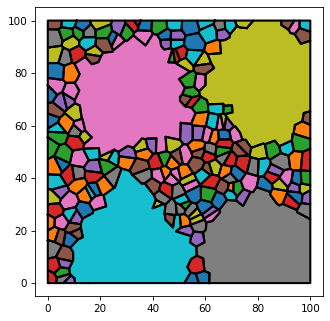

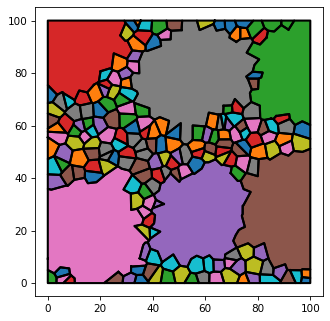

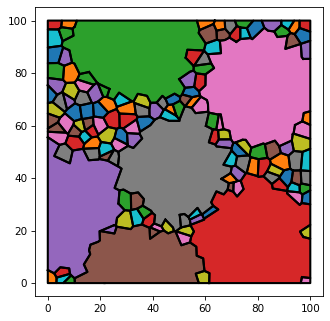

In [5]:
# Calculate the cluster instances
cinst = gset.add_supcell_instances(gslevel='base', instance=1,
         cluster_On=3, cell_sep_distance=2, n_supcell_instances=4,
         rand_exclude_cluster_centre_cids=0.0,
         exclude_cluster_centre_cids=[],
         exclude_cluster_cids=[], ccif=1.0,
         remove_duplicate_cells=True, merge=True, sample_plot=True, throw=True)

In [6]:
cinst.keys()

dict_keys(['name', 'scells', 'scells_coll', 'pxtals', 'info', 'inst', 'ninst', 'nclust', 'ncells'])

In [7]:
base_instance = 1
supgs_instance = 0

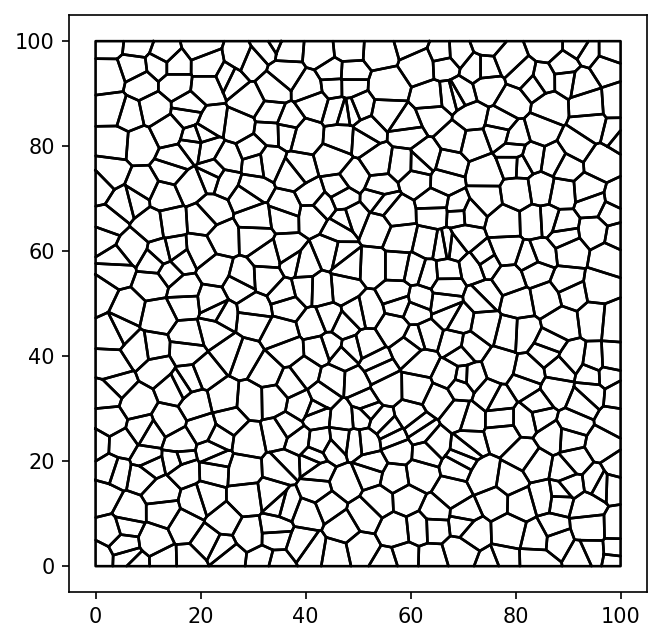

In [8]:
plt.figure(figsize=(5, 5), dpi=150)
pxtal = gset.pxtals[base_instance]
coords_cid = [np.vstack(c.boundary.xy).T for c in pxtal.geoms]
for vc in coords_cid:
    plt.plot(vc[:, 0], vc[:, 1], '-k', linewidth=1.25)
plt.gca().set_aspect('equal')

In [9]:
gset.fdb_supset.keys()

dict_keys(['name', 'scells', 'scells_coll', 'pxtals', 'info', 'inst', 'ninst', 'nclust', 'ncells'])

In [10]:
gset.fdb_supset['scells'].keys()  # Super cell instance IDs

dict_keys([1, 2, 3, 4])

In [11]:
gset.fdb_supset['scells'][1].keys()

dict_keys(['clids', 'cids', 'clusters'])

In [12]:
gset.fdb_supset['scells'][1]['clids']

[1, 2, 3, 4, 5, 6, 7]

In [13]:
cids = gset.fdb_supset['scells'][1]['cids']  # Cluster wise centre cell IDs
cids

[139, 174, 238, 81, 19, 436, 472]

In [14]:
supercell_centres = gset.fdb_supset['scells'][1]['clusters']
print(f'Numbr of super cell clusters: {len(supercell_centres)}\n', 20*'- ')
print(f'supercell centres cids are: \n\n', supercell_centres, '\n', 20*'- ')

Numbr of super cell clusters: 7
 - - - - - - - - - - - - - - - - - - - - 
supercell centres cids are: 

 [[127, 130, 131, 4, 132, 138, 149, 22, 151, 157, 34, 35, 37, 38, 172, 173, 47, 177, 178, 184, 185, 59, 65, 71, 199, 75, 206, 85, 214, 88, 92, 94, 224, 105, 106, 112, 118, 119, 122, 139], [383, 385, 390, 392, 393, 267, 400, 401, 410, 412, 290, 293, 422, 425, 298, 299, 304, 440, 315, 443, 446, 320, 321, 325, 331, 471, 346, 347, 355, 359, 360, 233, 364, 365, 372, 174], [256, 257, 258, 260, 269, 274, 276, 277, 278, 280, 281, 284, 287, 288, 291, 292, 294, 295, 297, 300, 303, 306, 309, 310, 312, 314, 319, 322, 323, 326, 327, 330, 333, 336, 338, 342, 348, 349, 363, 367, 140, 144, 147, 159, 161, 162, 168, 176, 183, 187, 188, 191, 192, 193, 194, 197, 201, 202, 203, 211, 217, 218, 221, 225, 228, 230, 232, 234, 235, 237, 239, 241, 243, 245, 246, 248, 250, 253, 254, 238], [128, 129, 2, 135, 8, 9, 136, 12, 13, 141, 142, 148, 21, 24, 153, 26, 155, 29, 30, 31, 32, 33, 158, 40, 169, 44, 48, 49, 52,

In [15]:
print('Cluster IDs are:', gset.fdb_supset['scells_coll'].keys())

Cluster IDs are: dict_keys([1, 2, 3, 4])


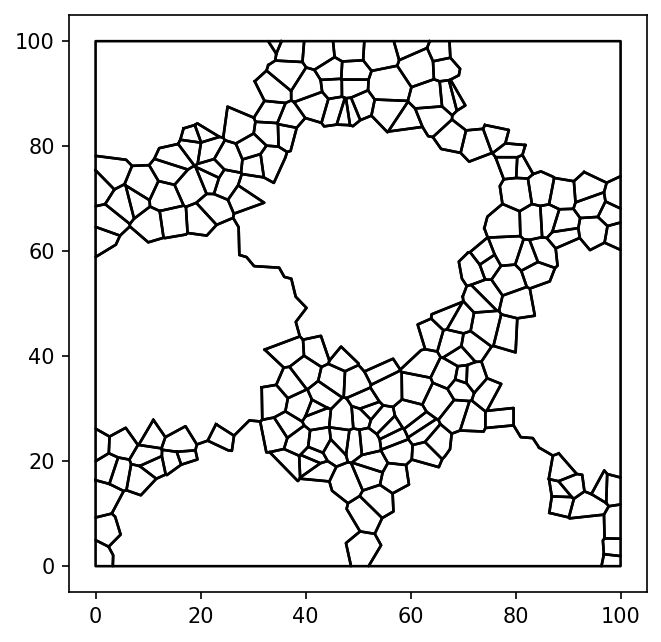

In [16]:
plt.figure(figsize=(5, 5), dpi=150)
pxtal = gset.fdb_supset['pxtals'][supgs_instance]
coords_cid = [np.vstack(c.boundary.xy).T for c in pxtal.geoms]
for vc in coords_cid:
    plt.plot(vc[:, 0], vc[:, 1], '-k', linewidth=1.25)
plt.gca().set_aspect('equal')

In [17]:
gset.fdb_supset['pxtals']  # Shapely Multi-Polygon objects.

[<MULTIPOLYGON (((3.579 71.75, 1.815 68.954, 0 68.558, 0 75.406, 3.579 71.75)...>,
 <MULTIPOLYGON (((3.579 71.75, 1.815 68.954, 0 68.558, 0 75.406, 3.579 71.75)...>,
 <MULTIPOLYGON (((3.579 71.75, 1.815 68.954, 0 68.558, 0 75.406, 3.579 71.75)...>,
 <MULTIPOLYGON (((3.579 71.75, 1.815 68.954, 0 68.558, 0 75.406, 3.579 71.75)...>]

In [18]:
print(gset.fdb_supset['pxtals'][1].geoms[0])

POLYGON ((3.578900337446448 71.75027244921152, 1.8148746512946428 68.95389263798697, 0 68.55782021516708, 0 75.40586776607819, 3.578900337446448 71.75027244921152))


In [19]:
gset.fdb_supset['info']

{'super_cell_name': 'grain_clusters',
 'source.gslevel': 'base',
 'source.instance': 1,
 'cluster_On': 3,
 'cell_sep_distance': 2,
 'n_supcell_instances': 4,
 'rand_exclude_cluster_centre_cids': 0.0,
 'exclude_cluster_centre_cids': [],
 'exclude_cluster_cids': [],
 'ccif': 1.0,
 'remove_duplicate_cells': True}

In [20]:
gset.fdb_supset['nclust']  # Number of clusters across instances

[7, 4, 6, 6]

Exaplanations
-------------
Note: This uses the above data access. Please refer it before reading
further.

gset.fdb_supset['ninst'] is 5, meaning there are 5 instances of
grain structures. Each instance has grain clusters. Each of the 5
pxtals can be accessed in gset.fdb_supset['pxtals']. Now, we see that
gset.fdb_supset['nclust'][pxtal_ID = 0] is 7. This means that in the
pxtal gset.fdb_supset['pxtals'][pxtal_ID], 7 grain clusters have been
created as 7 unique grains. That is, in each grain cluster, the n cell
which form n participating elements of the cluster, have all been made
a single cell through cell union operation. The participating cells in
a particular cluster, say the 1st cluster, i.e. the cluster
gset.fdb_supset['scells'][supcell instance ID = 1]['clids'][0] has the
cell ID gset.fdb_supset['scells'][supcell instance ID = 1]['cids'][0]
as 131. This means that the centre cell of the 1st cell cluster, is
cid = 131. Now,
gset.fdb_supset['scells'][supcell inst ID = 1]['clusters'][0], is
[159, 132, 134, 166, 167, 74, 111, 145, 114, 150, 119, 131]. Lets call
it as Ci_Cells. These are all cells which cluster aroung cid of 131.
The actual cells which have been unioned (i.e. merged) are
[gset.pxtals[1].geoms[i] for i in Ci_Cells], where
Ci_Cells = gset.fdb_supset['scells'][1]['clusters'][0]. Lets call this
Ci_Cells_geom. Ci_Cells_geom is a list of Shapely polygon objects.
Its multi-polygon can be easily created as MultiPolygon(Ci_Cells_geom).